# Messi, six sigma e o problema do denominador

Este notebook transforma a critica conceitual em uma analise reproduzivel. A pergunta nao e se Lionel Messi foi extraordinario. Ele foi. A pergunta estatistica correta e outra:

> O numero "1 a cada centenas de milhoes" mede habilidade individual ou mede uma escolha especifica de amostra, metrica e modelo probabilistico?

A analise viral usa uma ideia simples: calcular quantos desvios-padrao o valor de Messi em gols + assistencias por 90 minutos (`G+A/90`) esta acima da media. Isso e util como descricao, mas pode virar uma conclusao enganosa quando tratado como probabilidade objetiva.

Neste notebook vamos:

1. replicar a logica do z-score;
2. mostrar como o resultado muda quando alteramos o universo de comparacao;
3. incorporar contexto de equipe, porque futebol nao e uma medicao individual isolada;
4. separar o que e evidencia estatistica do que e retorica visual.

## Tese da analise

A estatistica "Messi esta a quase 6 desvios-padrao da media" depende de quatro decisoes que precisam ser explicitadas:

- **Metrica:** gols + assistencias por 90 minutos (`G+A/90`).
- **Denominador:** todos os jogadores, apenas atacantes, atacantes titulares, atacantes de times fortes etc.
- **Unidade de analise:** jogador-temporada ou carreira agregada por jogador.
- **Modelo probabilistico:** transformar um z-score em probabilidade pressupoe uma cauda normal, o que e forte demais para uma metrica nao negativa, assimetrica e dependente de oportunidade.

A proposta aqui e manter Messi como referencia, mas testar a estabilidade da conclusao sob amostras mais coerentes.

## Dados

Usaremos o arquivo publico `big5_player_standard.rds`, do repositorio `worldfootballR_data`, com dados do FBref para as cinco grandes ligas europeias.

A fonte nao e perfeita para medir "habilidade individual pura", mas e suficiente para demonstrar o ponto metodologico: a leitura muda quando a populacao de comparacao muda.

Observacao importante: o notebook baixa o arquivo bruto para `data/raw/` caso ele ainda nao exista.

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve
import math

import numpy as np
import pandas as pd
import pyreadr
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

In [ ]:
# Permite executar o notebook pela raiz do repositorio ou pela pasta do projeto.
if (Path.cwd() / "messi_six_sigma_analise_contextual.ipynb").exists():
    PROJECT_DIR = Path.cwd()
elif (Path.cwd() / "messi-six-sigma").exists():
    PROJECT_DIR = Path.cwd() / "messi-six-sigma"
else:
    PROJECT_DIR = Path.cwd()

In [ ]:
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
DERIVED_DIR = DATA_DIR / "derived"
RAW_DIR.mkdir(parents=True, exist_ok=True)
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_URL = (
    "https://raw.githubusercontent.com/JaseZiv/worldfootballR_data/master/"
    "data/fb_big5_advanced_season_stats/big5_player_standard.rds"
)
RDS_PATH = RAW_DIR / "big5_player_standard.rds"

PROJECT_DIR

WindowsPath('c:/WorkspaceHub/SourceHub/data-scientist/messi-six-sigma')

In [2]:
if not RDS_PATH.exists():
    print(f"Baixando dados para {RDS_PATH}...")
    urlretrieve(SOURCE_URL, RDS_PATH)
else:
    print(f"Usando cache local: {RDS_PATH}")

rds = pyreadr.read_r(str(RDS_PATH))
raw = next(iter(rds.values()))

raw.shape

Usando cache local: c:\WorkspaceHub\SourceHub\data-scientist\messi-six-sigma\data\raw\big5_player_standard.rds


(38008, 34)

## Preparacao dos dados

A base vem em nivel jogador-temporada. Vamos padronizar colunas numericas, calcular `G+A/90` diretamente a partir de gols, assistencias e minutos, e criar marcadores de posicao.

Tambem construiremos uma medida simples de contexto ofensivo do time: gols do time por 90 minutos na temporada. Ela nao captura toda a qualidade coletiva, mas ja aproxima uma parte da oportunidade disponivel para um atacante.

In [ ]:
numeric_cols = [
    "Season_End_Year", "MP_Playing", "Starts_Playing", "Min_Playing",
    "Mins_Per_90_Playing", "Gls", "Ast", "G+A_Per", "G_minus_PK",
    "PK", "PKatt", "Gls_Per", "Ast_Per", "G+A_minus_PK_Per",
    "xG_Expected", "xAG_Expected", "xG+xAG_Per",
]

In [ ]:
def prepare_player_seasons(raw_df: pd.DataFrame) -> pd.DataFrame:
    df = raw_df.copy()
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df[df["Min_Playing"].notna() & df["Min_Playing"].gt(0)].copy()
    df["Gls"] = df["Gls"].fillna(0)
    df["Ast"] = df["Ast"].fillna(0)
    df["goal_assist_total"] = df["Gls"] + df["Ast"]
    df["goals_assists_per90"] = df["goal_assist_total"] / (df["Min_Playing"] / 90)
    df["xg_xag_total"] = df["xG_Expected"].fillna(0) + df["xAG_Expected"].fillna(0)
    df["xg_xag_per90_calc"] = df["xg_xag_total"] / (df["Min_Playing"] / 90)
    df["is_forward"] = df["Pos"].fillna("").str.contains("FW", regex=False)
    df["is_primary_forward"] = df["Pos"].fillna("").str.startswith("FW")
    df["season"] = (
        (df["Season_End_Year"] - 1).astype("Int64").astype(str)
        + "-"
        + df["Season_End_Year"].astype("Int64").astype(str).str[-2:]
    )
    return df.replace([np.inf, -np.inf], np.nan)

,linhas_jogador_temporada,jogadores_unicos,temporada_inicial,temporada_final,linhas_de_atacantes
0,38008,10160,2010,2023,11366


In [ ]:
df = prepare_player_seasons(raw)

summary = pd.DataFrame({
    "linhas_jogador_temporada": [len(df)],
    "jogadores_unicos": [df["Player"].nunique()],
    "temporada_inicial": [int(df["Season_End_Year"].min())],
    "temporada_final": [int(df["Season_End_Year"].max())],
    "linhas_de_atacantes": [int(df["is_forward"].sum())],
})

summary

In [ ]:
def add_team_context(player_seasons: pd.DataFrame) -> pd.DataFrame:
    team_seasons = (
        player_seasons
        .groupby(["Season_End_Year", "Comp", "Squad"], as_index=False)
        .agg(
            team_minutes=("Min_Playing", "sum"),
            team_goals=("Gls", "sum"),
            team_goal_assists=("goal_assist_total", "sum"),
            team_xg=("xG_Expected", "sum"),
            team_xag=("xAG_Expected", "sum"),
        )
    )
    team_seasons["team_matches_90"] = team_seasons["team_minutes"] / (11 * 90)
    team_seasons["team_goals_per90"] = team_seasons["team_goals"] / team_seasons["team_matches_90"]
    team_seasons["team_goal_assists_per90"] = team_seasons["team_goal_assists"] / team_seasons["team_matches_90"]
    team_seasons["team_attack_percentile"] = (
        team_seasons
        .groupby(["Season_End_Year", "Comp"])["team_goals_per90"]
        .rank(pct=True)
    )
    team_seasons["is_elite_attack_team"] = team_seasons["team_attack_percentile"].ge(0.80)

    cols = [
        "Season_End_Year", "Comp", "Squad", "team_goals_per90",
        "team_goal_assists_per90", "team_attack_percentile", "is_elite_attack_team",
    ]
    return player_seasons.merge(team_seasons[cols], on=["Season_End_Year", "Comp", "Squad"], how="left")


,season,Comp,Squad,Player,Pos,Min_Playing,goals_assists_per90,team_goals_per90,team_attack_percentile,is_elite_attack_team
0,2009-10,La Liga,Almería,Santiago Acasiete,DF,"2,735.000",0.033,1.061,0.400,False
1,2009-10,La Liga,Almería,Diego Alves,GK,"3,302.000",0.000,1.061,0.400,False
2,2009-10,La Liga,Almería,Miguel Ángel Nieto,MF,418.000,0.000,1.061,0.400,False
3,2009-10,La Liga,Almería,Hernán Bernardello,MF,"3,033.000",0.059,1.061,0.400,False
4,2009-10,La Liga,Almería,Leonardo Borzani,MF,182.000,0.000,1.061,0.400,False


In [ ]:
df = add_team_context(df)

df[[
    "season", "Comp", "Squad", "Player", "Pos", "Min_Playing",
    "goals_assists_per90", "team_goals_per90", "team_attack_percentile",
    "is_elite_attack_team",
]].head()

## O valor de Messi usado como referencia

A publicacao viral menciona `1,45 G+A/90`. Vamos usar esse valor como referencia externa (`MESSI_VALUE_FROM_POST = 1.45`) e tambem calcular o valor de carreira de Messi no proprio dump.

Isso evita misturar duas coisas diferentes: o numero citado no post e o numero obtido pela nossa agregacao.

In [5]:
MESSI_VALUE_FROM_POST = 1.45

messi_rows = (
    df[df["Player"].eq("Lionel Messi")]
    [[
        "season", "Season_End_Year", "Squad", "Comp", "Pos", "Min_Playing",
        "Gls", "Ast", "goals_assists_per90", "team_goals_per90",
        "team_attack_percentile",
    ]]
    .sort_values("Season_End_Year")
)

messi_rows

,season,Season_End_Year,Squad,Comp,Pos,Min_Playing,Gls,Ast,goals_assists_per90,team_goals_per90,team_attack_percentile
209,2009-10,2010,Barcelona,La Liga,"FW,MF","2,805.000",34.000,9.000,1.380,2.507,0.950
2916,2010-11,2011,Barcelona,La Liga,"FW,MF","2,858.000",31.000,19.000,1.575,2.475,0.950
5648,2011-12,2012,Barcelona,La Liga,"FW,MF","3,270.000",50.000,16.000,1.817,2.957,0.950
8358,2012-13,2013,Barcelona,La Liga,"FW,MF","2,650.000",46.000,11.000,1.936,2.953,1.000
11140,2013-14,2014,Barcelona,La Liga,"FW,MF","2,501.000",28.000,11.000,1.403,2.527,0.950
13856,2014-15,2015,Barcelona,La Liga,"FW,MF","3,375.000",43.000,18.000,1.627,2.824,0.950
16549,2015-16,2016,Barcelona,La Liga,FW,"2,729.000",26.000,14.000,1.319,2.869,1.000
19318,2016-17,2017,Barcelona,La Liga,FW,"2,830.000",37.000,9.000,1.463,2.976,1.000
22078,2017-18,2018,Barcelona,La Liga,FW,"3,000.000",34.000,12.000,1.380,2.531,1.000
24765,2018-19,2019,Barcelona,La Liga,FW,"2,713.000",36.000,13.000,1.626,2.320,1.000


## Carreira agregada por jogador

Para comparar jogadores com mais estabilidade, agregaremos temporadas por jogador. Isso reduz a distorcao de temporadas com poucos minutos, mas cria outra decisao metodologica: jogadores com carreiras longas e curtas passam a ocupar uma linha cada.

Essa escolha e defensavel para replicar o grafico viral, desde que fique explicita.

In [ ]:
def aggregate_by_player(data: pd.DataFrame) -> pd.DataFrame:
    temp = data.copy()
    temp["weighted_team_goals_per90"] = temp["team_goals_per90"] * temp["Min_Playing"]
    temp["elite_minutes_component"] = np.where(temp["is_elite_attack_team"], temp["Min_Playing"], 0)

    out = (
        temp.groupby("Player", as_index=False)
        .agg(
            Min_Playing=("Min_Playing", "sum"),
            Gls=("Gls", "sum"),
            Ast=("Ast", "sum"),
            xG=("xG_Expected", "sum"),
            xAG=("xAG_Expected", "sum"),
            seasons=("Season_End_Year", "nunique"),
            first_season=("Season_End_Year", "min"),
            last_season=("Season_End_Year", "max"),
            weighted_team_goals_per90=("weighted_team_goals_per90", "sum"),
            elite_minutes=("elite_minutes_component", "sum"),
        )
    )

    out["goals_assists_per90"] = (out["Gls"] + out["Ast"]) / (out["Min_Playing"] / 90)
    out["xg_xag_per90"] = (out["xG"].fillna(0) + out["xAG"].fillna(0)) / (out["Min_Playing"] / 90)
    out["team_goals_per90_context"] = out["weighted_team_goals_per90"] / out["Min_Playing"]
    out["elite_minutes_share"] = out["elite_minutes"] / out["Min_Playing"]
    return out.replace([np.inf, -np.inf], np.nan)


,Player,Min_Playing,Gls,Ast,xG,xAG,seasons,first_season,last_season,weighted_team_goals_per90,elite_minutes,goals_assists_per90,xg_xag_per90,team_goals_per90_context,elite_minutes_share
1405,Hicham Khaloua,4.000,1.000,0.000,0.000,0.000,1,2014,2014,4.540,0.000,22.500,0.000,1.135,0.000
1255,Georges-Kévin N'Koudou,5.000,0.000,1.000,0.000,0.500,1,2019,2019,8.707,5.000,18.000,9.000,1.741,1.000
2184,Luigi Samele,5.000,0.000,1.000,0.000,0.400,1,2022,2022,7.905,0.000,18.000,7.200,1.581,0.000
1526,Jack Lahne,9.000,1.000,0.000,0.400,0.000,1,2020,2020,9.703,0.000,10.000,4.000,1.078,0.000
2124,Losada,13.000,1.000,0.000,0.300,0.000,1,2020,2020,12.745,0.000,6.923,2.077,0.980,0.000
1893,Juvhel Tsoumou,15.000,1.000,0.000,0.000,0.000,1,2010,2010,20.818,0.000,6.000,0.000,1.388,0.000
2706,Niklas Schmidt,15.000,0.000,1.000,0.000,0.000,1,2017,2017,26.903,0.000,6.000,0.000,1.794,0.000
1215,Gabriel Vidovic,19.000,0.000,1.000,0.000,0.100,1,2023,2023,58.588,19.000,4.737,0.474,3.084,1.000
449,Borja Garcés,20.000,1.000,0.000,0.500,0.000,1,2019,2019,28.017,20.000,4.500,2.250,1.401,1.000
660,Cristian Volpato,72.000,2.000,1.000,0.300,1.300,2,2022,2023,103.428,0.000,3.750,2.000,1.436,0.000


In [ ]:
career_all = aggregate_by_player(df)
career_fw = aggregate_by_player(df[df["is_forward"]])
career_primary_fw = aggregate_by_player(df[df["is_primary_forward"]])

career_path = DERIVED_DIR / "messi_contextual_career_attackers.csv"
career_fw.to_csv(career_path, index=False)

career_fw.sort_values("goals_assists_per90", ascending=False).head(10)

## Funcoes estatisticas

O z-score e uma padronizacao:

$$
z = \frac{x - \mu}{\sigma}
$$

Ele responde: "quantos desvios-padrao este valor esta acima da media da amostra?".

Mas o salto de z-score para "1 a cada N jogadores" exige uma hipotese adicional: que a cauda siga uma distribuicao normal. Essa hipotese sera tratada como aproximacao retorica, nao como verdade literal.

In [7]:
def normal_one_in(z: float) -> float:
    # Converte z-score em frequencia "1 em N" sob cauda normal unilateral.
    tail_probability = 0.5 * math.erfc(z / math.sqrt(2))
    if tail_probability == 0:
        return np.inf
    return 1 / tail_probability


def summarize_distribution(label: str, series: pd.Series, value: float = MESSI_VALUE_FROM_POST) -> dict:
    s = pd.to_numeric(series, errors="coerce").dropna()
    s = s[np.isfinite(s)]
    mean = s.mean()
    std = s.std(ddof=1)
    z = (value - mean) / std
    return {
        "cenario": label,
        "n": len(s),
        "media": mean,
        "desvio_padrao": std,
        "valor_referencia": value,
        "z_score": z,
        "normal_1_em_n": normal_one_in(z),
        "observados_acima_ou_igual": int((s >= value).sum()),
        "taxa_empirica_acima_ou_igual": (s >= value).mean(),
    }


def add_z_score(data: pd.DataFrame, column: str, value_column_name: str = "z_score") -> pd.DataFrame:
    out = data.copy()
    mean = out[column].mean()
    std = out[column].std(ddof=1)
    out[value_column_name] = (out[column] - mean) / std
    return out

## 1. Replicando a leitura favoravel ao "6 sigma"

Quando usamos uma linha por jogador, apenas atacantes (`Pos` contem `FW`) e minimo de 900 minutos no agregado, o valor `1,45` fica proximo de 6 desvios-padrao acima da media.

Essa e a parte verdadeira da analise viral: sob esse recorte, Messi e um outlier extremo.

In [8]:
MIN_MINUTES = 900
base_fw = career_fw[career_fw["Min_Playing"].ge(MIN_MINUTES)].copy()
base_fw = add_z_score(base_fw, "goals_assists_per90")

mu_fw = base_fw["goals_assists_per90"].mean()
sd_fw = base_fw["goals_assists_per90"].std(ddof=1)
z_post_fw = (MESSI_VALUE_FROM_POST - mu_fw) / sd_fw

messi_career_value = base_fw.loc[base_fw["Player"].eq("Lionel Messi"), "goals_assists_per90"].iloc[0]
z_messi_career = (messi_career_value - mu_fw) / sd_fw

pd.DataFrame([
    {
        "comparacao": "valor do post: 1.45 vs atacantes Big 5 agregados",
        "n": len(base_fw),
        "media": mu_fw,
        "desvio_padrao": sd_fw,
        "valor": MESSI_VALUE_FROM_POST,
        "z_score": z_post_fw,
        "normal_1_em_n": normal_one_in(z_post_fw),
    },
    {
        "comparacao": "Messi carreira Big 5 calculado no dump",
        "n": len(base_fw),
        "media": mu_fw,
        "desvio_padrao": sd_fw,
        "valor": messi_career_value,
        "z_score": z_messi_career,
        "normal_1_em_n": normal_one_in(z_messi_career),
    },
])

,comparacao,n,media,desvio_padrao,valor,z_score,normal_1_em_n
0,valor do post: 1.45 vs atacantes Big 5 agregados,2038,0.376,0.183,1.450,5.865,"444,847,375.338"
1,Messi carreira Big 5 calculado no dump,2038,0.376,0.183,1.472,5.986,"932,029,144.091"


In [9]:
key_players = [
    "Lionel Messi",
    "Cristiano Ronaldo",
    "Kylian Mbappé",
    "Kylian Mbappe",
    "Erling Haaland",
    "Robert Lewandowski",
]

key_table = (
    base_fw[base_fw["Player"].isin(key_players)]
    [[
        "Player", "Min_Playing", "Gls", "Ast", "goals_assists_per90",
        "xg_xag_per90", "team_goals_per90_context", "elite_minutes_share", "z_score",
    ]]
    .sort_values("z_score", ascending=False)
)

key_table

,Player,Min_Playing,Gls,Ast,goals_assists_per90,xg_xag_per90,team_goals_per90_context,elite_minutes_share,z_score
2113,Lionel Messi,"37,840.000",433.000,186.000,1.472,0.425,2.595,1.000,5.986
1018,Erling Haaland,"6,301.000",79.000,19.000,1.400,1.050,2.411,1.000,5.591
2031,Kylian Mbappé,"14,189.000",146.000,54.000,1.269,1.018,2.498,1.000,4.874
663,Cristiano Ronaldo,"36,411.000",411.000,101.000,1.266,0.363,2.481,0.920,4.857
3017,Robert Lewandowski,"31,997.000",325.000,60.000,1.083,0.547,2.502,1.000,3.860


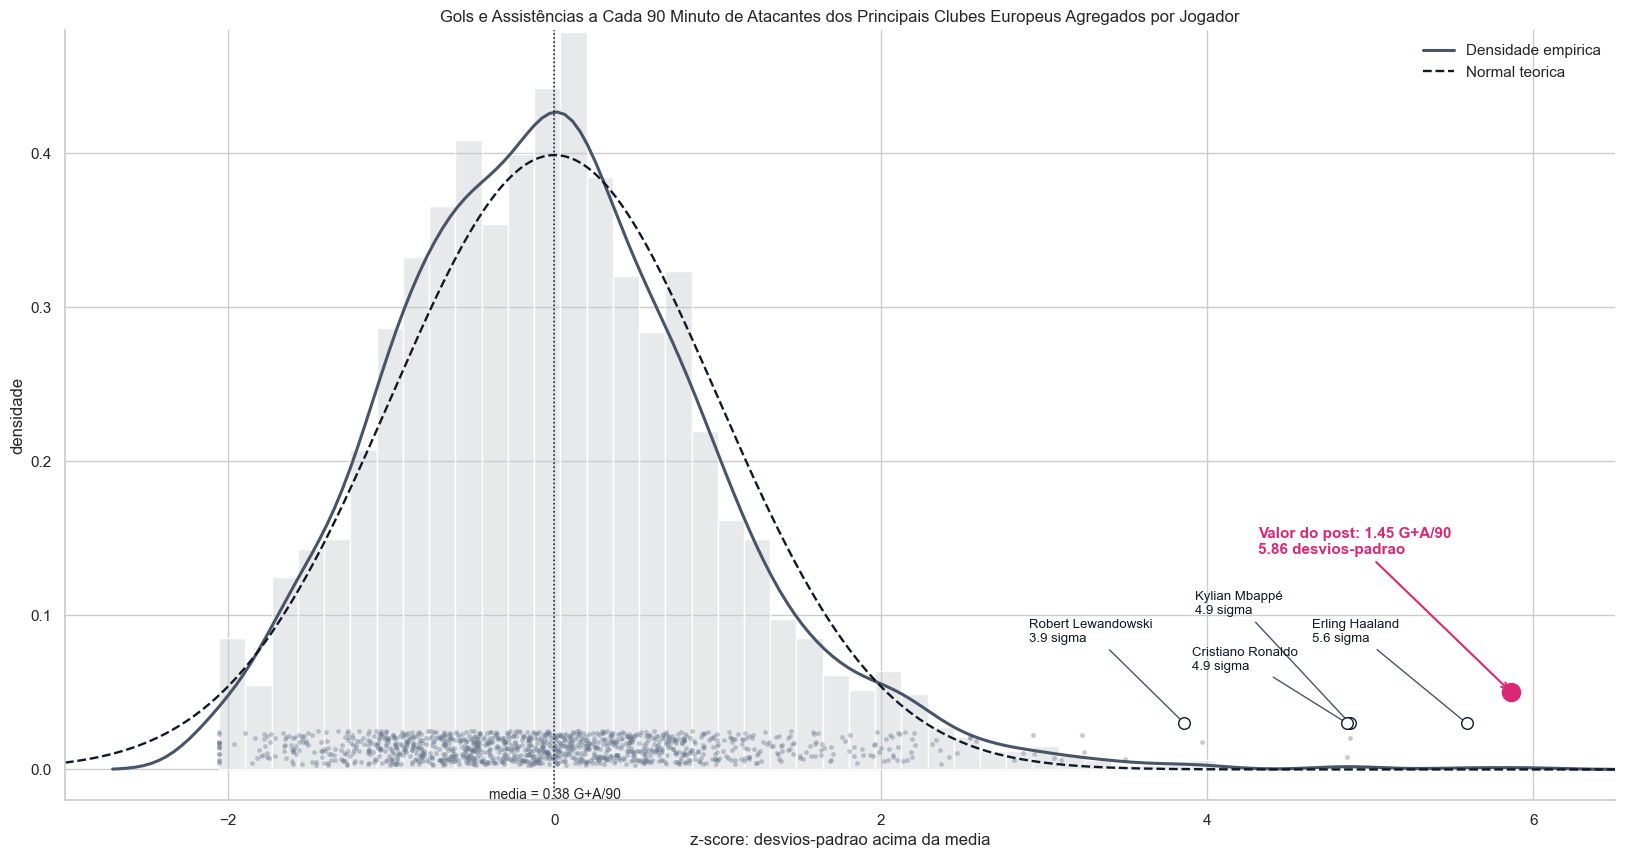

In [21]:
plot_base = base_fw.copy()
x_min = min(-3, float(plot_base["z_score"].min()) - 0.2)
x_max = max(6.5, float(plot_base["z_score"].max()) + 0.2)
x = np.linspace(x_min, x_max, 600)
normal_pdf = np.exp(-0.5 * x**2) / math.sqrt(2 * math.pi)

fig, ax = plt.subplots(figsize=(20, 10))

sns.histplot(
    plot_base["z_score"],
    bins=50,
    stat="density",
    color="#c5c9cf",
    alpha=0.40,
    edgecolor=None,
    ax=ax,
)
sns.kdeplot(plot_base["z_score"], color="#475569", linewidth=2.2, ax=ax, label="Densidade empirica")
ax.plot(x, normal_pdf, color="#111827", linewidth=1.7, linestyle="--", label="Normal teorica")

rng = np.random.default_rng(42)
sample = plot_base.sample(min(len(plot_base), 1_200), random_state=42)
ax.scatter(
    sample["z_score"],
    rng.uniform(0.003, 0.025, len(sample)),
    s=12,
    color="#64748b",
    alpha=0.38,
    linewidths=0,
)

ax.scatter([z_post_fw], [0.05], s=170, color="#db2777", zorder=5)
ax.annotate(
    f"Valor do post: 1.45 G+A/90\n{z_post_fw:.2f} desvios-padrao",
    xy=(z_post_fw, 0.05),
    xytext=(z_post_fw - 1.55, 0.14),
    arrowprops={"arrowstyle": "->", "color": "#db2777", "lw": 1.5},
    color="#db2777",
    fontsize=11,
    fontweight="bold",
)

for idx, row in key_table.reset_index(drop=True).iterrows():
    if row["Player"] == "Lionel Messi":
        continue
    ax.scatter([row["z_score"]], [0.03], s=70, color="#ffffff", edgecolor="#111827", zorder=4)
    ax.annotate(
        f"{row['Player']}\n{row['z_score']:.1f} sigma",
        xy=(row["z_score"], 0.03),
        xytext=(row["z_score"] - 0.95, 0.065 + 0.018 * (idx % 3)),
        arrowprops={"arrowstyle": "-", "color": "#475569", "lw": 1},
        fontsize=9.5,
        color="#111827",
    )

ax.axvline(0, color="#111827", linewidth=1.1, linestyle=":")
ax.text(0, -0.012, f"media = {mu_fw:.2f} G+A/90", ha="center", va="top", fontsize=10)
ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.02, max(0.48, normal_pdf.max() * 1.15))
ax.set_xlabel("z-score: desvios-padrao acima da media")
ax.set_ylabel("densidade")
ax.set_title("Gols e Assistências a Cada 90 Minuto de Atacantes dos Principais Clubes Europeus Agregados por Jogador")
ax.legend(loc="best", frameon=False)
sns.despine(ax=ax)
plt.show()

## 2. Sensibilidade: o denominador muda a conclusao

Agora vem o ponto central: a mesma marca de `1,45 G+A/90` pode parecer mais ou menos extrema dependendo do universo de comparacao.

Se compararmos Messi com todos os jogadores, a media cai muito. Se compararmos apenas com atacantes de times ofensivamente fortes, a media sobe. O numero de desvios-padrao deixa de ser uma propriedade fixa de Messi e passa a ser uma propriedade de Messi **em relacao a uma amostra escolhida**.

In [11]:
sensitivity_rows = [
    summarize_distribution(
        "jogador-temporada, todos, min 90",
        df[df["Min_Playing"].ge(90)]["goals_assists_per90"],
    ),
    summarize_distribution(
        "jogador-temporada, todos, min 900",
        df[df["Min_Playing"].ge(900)]["goals_assists_per90"],
    ),
    summarize_distribution(
        "jogador-temporada, atacantes, min 900",
        df[df["is_forward"] & df["Min_Playing"].ge(900)]["goals_assists_per90"],
    ),
    summarize_distribution(
        "jogador-temporada, atacantes de times top 20% ataque, min 900",
        df[df["is_forward"] & df["is_elite_attack_team"] & df["Min_Playing"].ge(900)]["goals_assists_per90"],
    ),
    summarize_distribution(
        "carreira, todos, min 900",
        career_all[career_all["Min_Playing"].ge(900)]["goals_assists_per90"],
    ),
    summarize_distribution(
        "carreira, atacantes, min 900",
        career_fw[career_fw["Min_Playing"].ge(900)]["goals_assists_per90"],
    ),
    summarize_distribution(
        "carreira, posicao principal FW, min 900",
        career_primary_fw[career_primary_fw["Min_Playing"].ge(900)]["goals_assists_per90"],
    ),
    summarize_distribution(
        "carreira, atacantes com >=50% dos minutos em times top 20% ataque",
        career_fw[
            career_fw["Min_Playing"].ge(900)
            & career_fw["elite_minutes_share"].ge(0.50)
        ]["goals_assists_per90"],
    ),
]

sensitivity = pd.DataFrame(sensitivity_rows).sort_values("z_score", ascending=False)
sensitivity

,cenario,n,media,desvio_padrao,valor_referencia,z_score,normal_1_em_n,observados_acima_ou_igual,taxa_empirica_acima_ou_igual
4,"carreira, todos, min 900",6416,0.184,0.183,1.450,6.933,"486,179,797,026.531",1,0.000
5,"carreira, atacantes, min 900",2038,0.376,0.183,1.450,5.865,"444,847,375.338",1,0.000
6,"carreira, posicao principal FW, min 900",1552,0.411,0.182,1.450,5.694,"161,542,703.030",1,0.001
1,"jogador-temporada, todos, min 900",21309,0.207,0.230,1.450,5.409,"31,612,402.703",23,0.001
0,"jogador-temporada, todos, min 90",33834,0.193,0.245,1.450,5.139,"7,223,468.364",64,0.002
2,"jogador-temporada, atacantes, min 900",5554,0.457,0.252,1.450,3.935,"23,995.347",23,0.004
7,"carreira, atacantes com >=50% dos minutos em t...",303,0.543,0.236,1.450,3.849,"16,874.230",1,0.003
3,"jogador-temporada, atacantes de times top 20% ...",1393,0.666,0.300,1.450,2.610,220.631,23,0.017


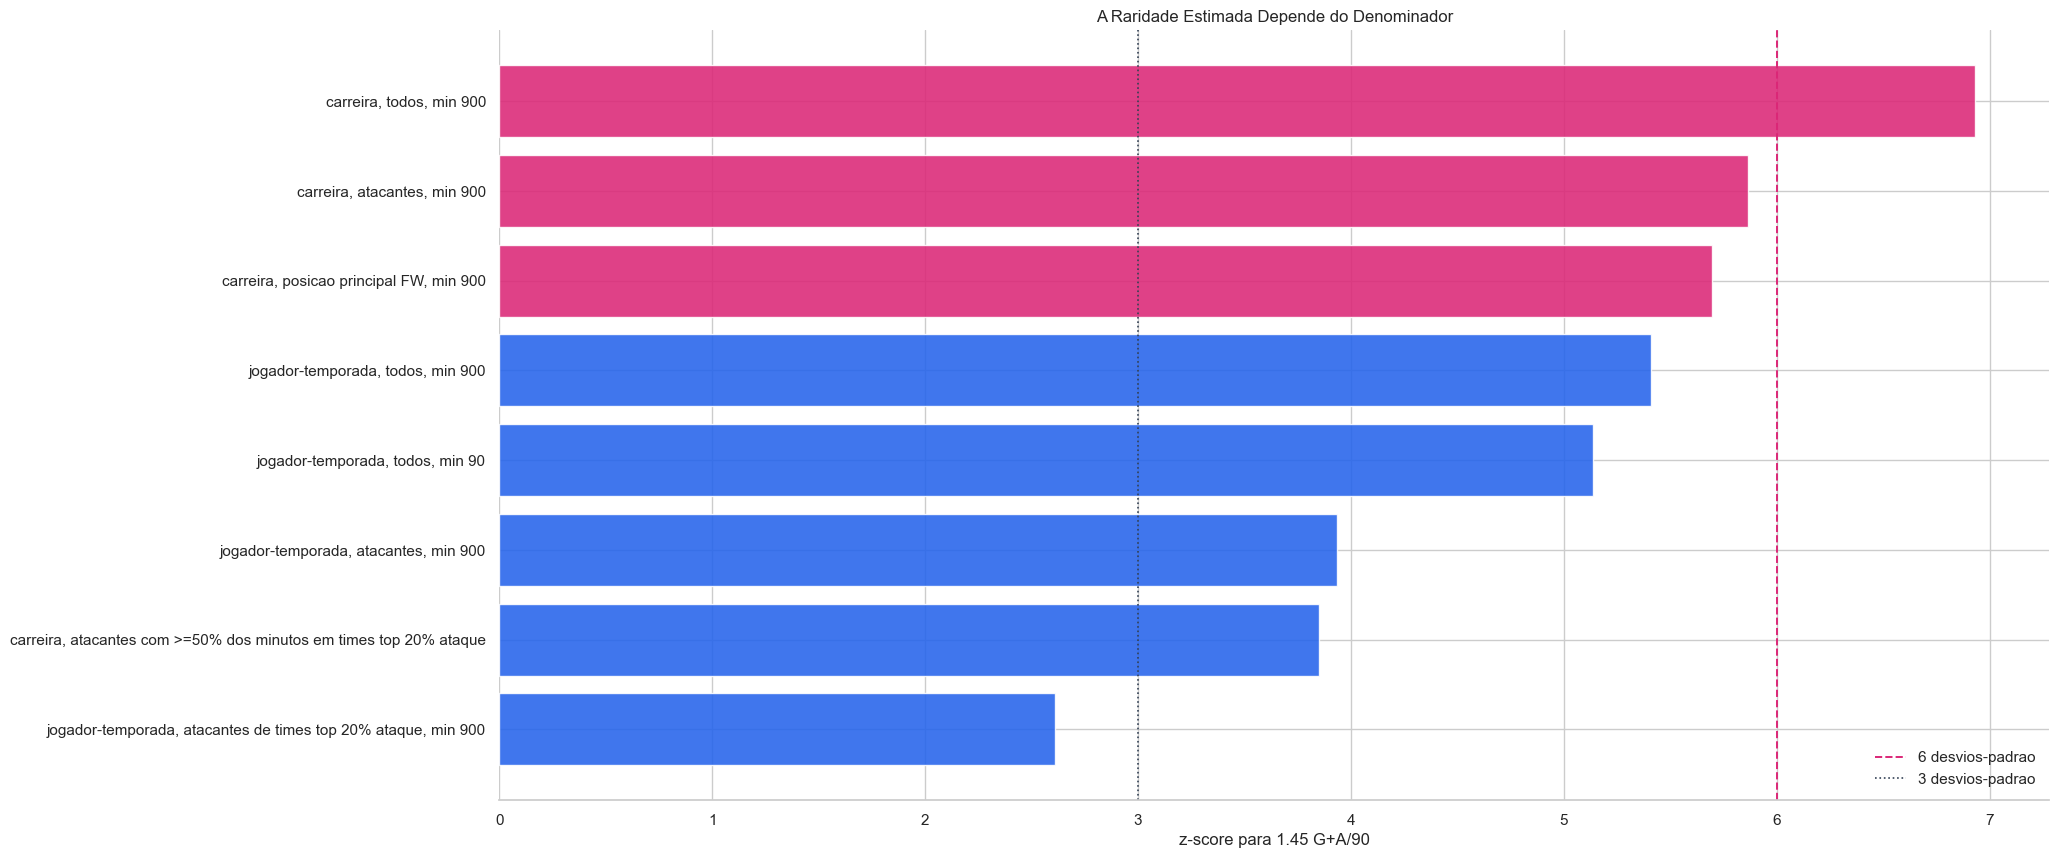

In [23]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_sens = sensitivity.sort_values("z_score")
colors = np.where(plot_sens["z_score"].ge(5.5), "#db2777", "#2563eb")

ax.barh(plot_sens["cenario"], plot_sens["z_score"], color=colors, alpha=0.88)
ax.axvline(6, color="#db2777", linestyle="--", linewidth=1.4, label="6 desvios-padrao")
ax.axvline(3, color="#334155", linestyle=":", linewidth=1.2, label="3 desvios-padrao")
ax.set_xlabel("z-score para 1.45 G+A/90")
ax.set_ylabel("")
ax.set_title("A Raridade Estimada Depende do Denominador")
ax.legend(frameon=False, loc="lower right")
sns.despine(ax=ax, left=True)
plt.show()

## 3. Contexto de equipe: oportunidade tambem entra na metrica

`G+A/90` nao mede apenas habilidade individual. Ele tambem mede volume e qualidade de oportunidades.

Um atacante em um time dominante tende a:

- receber mais bolas em zonas perigosas;
- jogar mais minutos em cenarios de pressao ofensiva;
- participar de mais sequencias que terminam em finalizacao;
- cobrar penaltis, faltas ou escanteios;
- virar o centro do plano ofensivo.

Nada disso tira merito do jogador. Ao contrario: muitas vezes o time concentra oportunidades nele justamente porque ele e excelente. Mas isso significa que `G+A/90` mistura habilidade, funcao, contexto e retroalimentacao tatica.

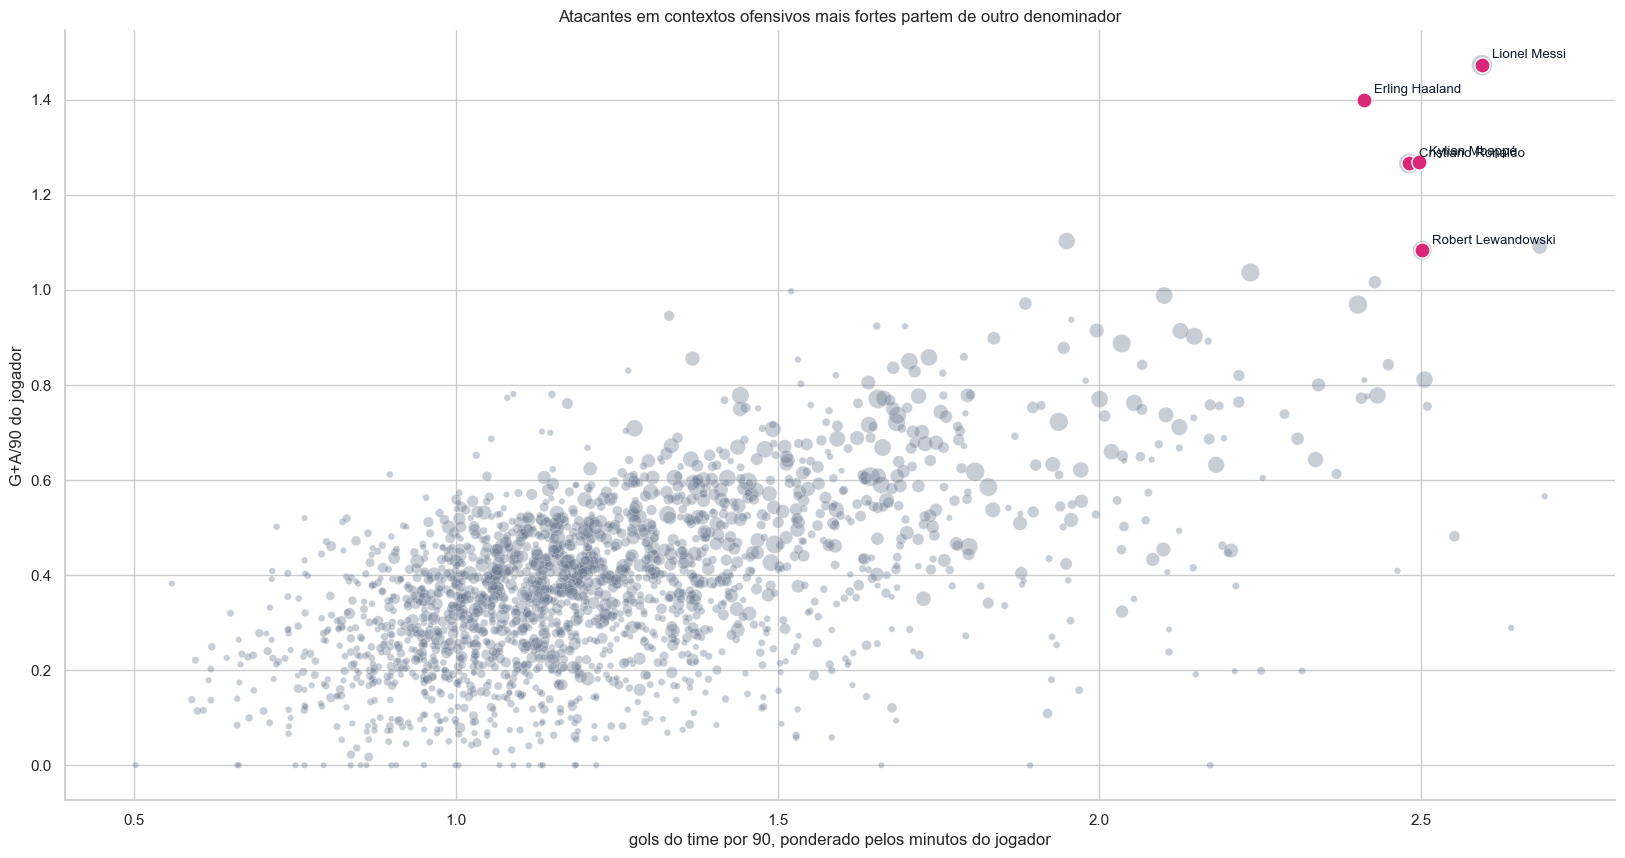

In [24]:
fig, ax = plt.subplots(figsize=(20, 10))
context_base = base_fw.dropna(subset=["team_goals_per90_context", "goals_assists_per90"]).copy()

sns.scatterplot(
    data=context_base,
    x="team_goals_per90_context",
    y="goals_assists_per90",
    size="Min_Playing",
    sizes=(20, 220),
    alpha=0.35,
    color="#64748b",
    legend=False,
    ax=ax,
)

highlight = context_base[context_base["Player"].isin(key_players)].copy()
sns.scatterplot(
    data=highlight,
    x="team_goals_per90_context",
    y="goals_assists_per90",
    s=120,
    color="#db2777",
    edgecolor="white",
    linewidth=1.0,
    ax=ax,
)

for _, row in highlight.iterrows():
    ax.annotate(
        row["Player"],
        xy=(row["team_goals_per90_context"], row["goals_assists_per90"]),
        xytext=(7, 5),
        textcoords="offset points",
        fontsize=9.5,
        color="#111827",
    )

ax.set_xlabel("gols do time por 90, ponderado pelos minutos do jogador")
ax.set_ylabel("G+A/90 do jogador")
ax.set_title("Atacantes em contextos ofensivos mais fortes partem de outro denominador")
sns.despine(ax=ax)
plt.show()

## 4. Uma comparacao contextual simples

Uma forma melhor de fazer a pergunta nao e "quantos sigmas Messi esta acima de todos?", mas:

> Dado o volume esperado de gols/assistencias do jogador e o contexto ofensivo do time, quanto ele ainda excede o padrao da amostra?

Abaixo usamos uma regressao linear simples, apenas como ajuste exploratorio, com duas variaveis:

- `xG + xAG por 90`: proxy de volume/qualidade de chances diretamente associadas ao jogador;
- gols do time por 90: proxy de forca ofensiva coletiva.

O residuo mostra quem continua acima do esperado depois desse ajuste. Isso ainda nao e "habilidade pura", mas e mais honesto do que comparar todo mundo em uma unica media bruta.

In [14]:
def fit_context_model(data: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    model_data = data.dropna(
        subset=["goals_assists_per90", "xg_xag_per90", "team_goals_per90_context"]
    ).copy()
    X = np.column_stack([
        np.ones(len(model_data)),
        model_data["xg_xag_per90"].to_numpy(),
        model_data["team_goals_per90_context"].to_numpy(),
    ])
    y = model_data["goals_assists_per90"].to_numpy()
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    fitted = X @ beta
    residual = y - fitted

    model_data["context_expected_ga90"] = fitted
    model_data["context_residual"] = residual
    model_data["context_residual_z"] = (
        model_data["context_residual"] - model_data["context_residual"].mean()
    ) / model_data["context_residual"].std(ddof=1)

    r2 = 1 - np.sum((y - fitted) ** 2) / np.sum((y - y.mean()) ** 2)
    model_info = {
        "intercepto": beta[0],
        "coef_xg_xag_per90": beta[1],
        "coef_gols_time_per90": beta[2],
        "r2": r2,
        "n": len(model_data),
    }
    return model_data, model_info


context_model, model_info = fit_context_model(base_fw)
pd.DataFrame([model_info])

,intercepto,coef_xg_xag_per90,coef_gols_time_per90,r2,n
0,-0.005,0.183,0.283,0.348,2038


In [15]:
context_key_table = (
    context_model[context_model["Player"].isin(key_players)]
    [[
        "Player", "goals_assists_per90", "xg_xag_per90", "team_goals_per90_context",
        "context_expected_ga90", "context_residual", "context_residual_z",
    ]]
    .sort_values("context_residual_z", ascending=False)
)

context_key_table

,Player,goals_assists_per90,xg_xag_per90,team_goals_per90_context,context_expected_ga90,context_residual,context_residual_z
2113,Lionel Messi,1.472,0.425,2.595,0.807,0.665,4.501
1018,Erling Haaland,1.400,1.050,2.411,0.870,0.530,3.586
663,Cristiano Ronaldo,1.266,0.363,2.481,0.763,0.502,3.397
2031,Kylian Mbappé,1.269,1.018,2.498,0.888,0.380,2.573
3017,Robert Lewandowski,1.083,0.547,2.502,0.803,0.280,1.893


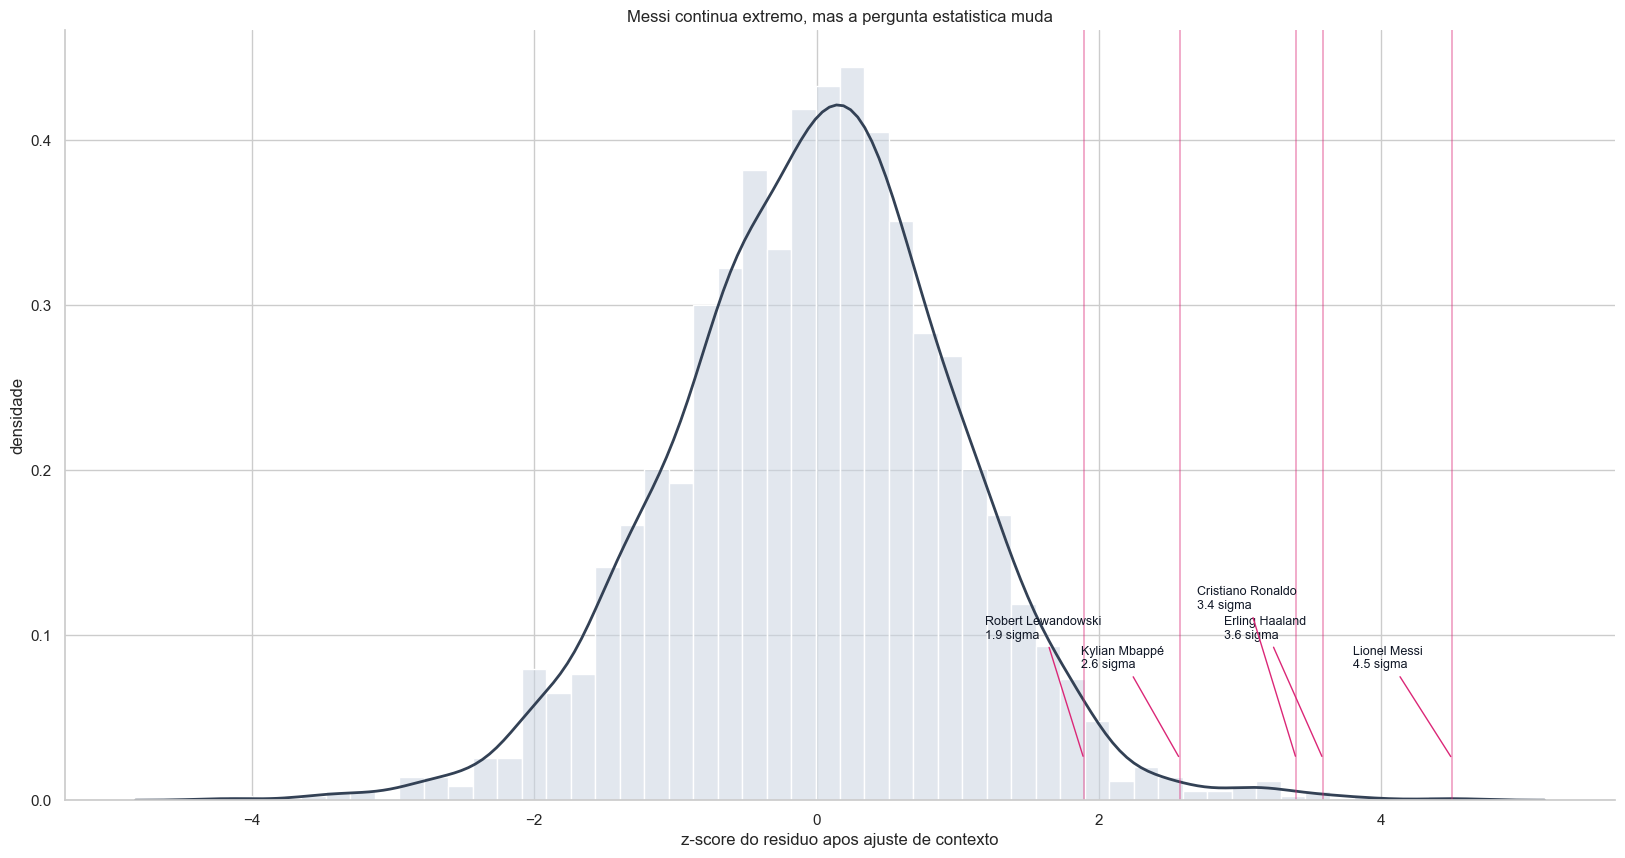

In [25]:
fig, ax = plt.subplots(figsize=(20, 10))

sns.histplot(
    context_model["context_residual_z"],
    bins=50,
    stat="density",
    color="#cbd5e1",
    alpha=0.55,
    edgecolor=None,
    ax=ax,
)
sns.kdeplot(context_model["context_residual_z"], color="#334155", linewidth=2, ax=ax)

for idx, row in context_key_table.reset_index(drop=True).iterrows():
    ax.axvline(row["context_residual_z"], color="#db2777", alpha=0.45, linewidth=1.2)
    ax.annotate(
        f"{row['Player']}\n{row['context_residual_z']:.1f} sigma",
        xy=(row["context_residual_z"], 0.025),
        xytext=(row["context_residual_z"] - 0.7, 0.08 + 0.018 * (idx % 3)),
        arrowprops={"arrowstyle": "-", "color": "#db2777", "lw": 1},
        fontsize=9,
        color="#111827",
    )

ax.set_xlabel("z-score do residuo apos ajuste de contexto")
ax.set_ylabel("densidade")
ax.set_title("Messi continua extremo, mas a pergunta estatistica muda")
sns.despine(ax=ax)
plt.show()

## 5. O problema da probabilidade "1 em N"

Quando dizemos que um z-score de 5,86 equivale a "1 em centenas de milhoes", estamos usando a cauda de uma normal teorica.

Isso e problematico porque `G+A/90`:

- nao pode ser negativo;
- tem cauda direita longa;
- e afetado por minutos jogados;
- e afetado por posicao, time, liga, funcao tatica e bola parada;
- nao representa uma amostra aleatoria de "habilidade humana".

Por isso, a coluna `normal_1_em_n` deve ser lida como: "se essa variavel se comportasse como uma normal na cauda". Ela nao prova que Messi literalmente so deveria aparecer uma vez a cada centenas de milhoes de jogadores.

In [17]:
probability_view = sensitivity[[
    "cenario", "n", "media", "desvio_padrao", "z_score",
    "normal_1_em_n", "observados_acima_ou_igual", "taxa_empirica_acima_ou_igual",
]].copy()

probability_view["normal_1_em_n"] = probability_view["normal_1_em_n"].map(lambda x: f"1 em {x:,.0f}")
probability_view["taxa_empirica_acima_ou_igual"] = probability_view["taxa_empirica_acima_ou_igual"].map(lambda x: f"{100*x:.3f}%")

probability_view

,cenario,n,media,desvio_padrao,z_score,normal_1_em_n,observados_acima_ou_igual,taxa_empirica_acima_ou_igual
4,"carreira, todos, min 900",6416,0.184,0.183,6.933,"1 em 486,179,797,027",1,0.016%
5,"carreira, atacantes, min 900",2038,0.376,0.183,5.865,"1 em 444,847,375",1,0.049%
6,"carreira, posicao principal FW, min 900",1552,0.411,0.182,5.694,"1 em 161,542,703",1,0.064%
1,"jogador-temporada, todos, min 900",21309,0.207,0.230,5.409,"1 em 31,612,403",23,0.108%
0,"jogador-temporada, todos, min 90",33834,0.193,0.245,5.139,"1 em 7,223,468",64,0.189%
2,"jogador-temporada, atacantes, min 900",5554,0.457,0.252,3.935,"1 em 23,995",23,0.414%
7,"carreira, atacantes com >=50% dos minutos em t...",303,0.543,0.236,3.849,"1 em 16,874",1,0.330%
3,"jogador-temporada, atacantes de times top 20% ...",1393,0.666,0.300,2.610,1 em 221,23,1.651%


## Conclusao

A analise viral contem uma intuicao verdadeira: Messi e um outlier absurdo em participacao direta em gols. No recorte de carreira agregada de atacantes Big 5, o valor `1,45 G+A/90` realmente fica perto de 6 desvios-padrao acima da media.

Mas a conclusao "estatisticamente, Messi nao deveria existir" e forte demais. O resultado depende do denominador e da hipotese de normalidade. Quando restringimos a comparacao para atacantes em contextos ofensivos mais parecidos, o z-score cai bastante. Quando ajustamos de forma exploratoria por oportunidade e contexto de equipe, Messi continua excepcional, mas a estatistica deixa de significar "probabilidade literal de existencia".

Uma formulacao mais correta seria:

> Em G+A/90, Messi e um outlier extremo entre atacantes das Big 5. A magnitude exata desse outlier, porem, depende da populacao de comparacao, da unidade de analise e do quanto controlamos por oportunidade coletiva. O numero "1 em centenas de milhoes" e uma extrapolacao baseada em normalidade, nao uma verdade objetiva sobre a chance de surgir um jogador como Messi.